The finite difference gradient did not appear to produce the same result as adjoint gradient method. Here the code is reproduced

In [2]:
import emg3d
import empymod
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

plt.style.use('bmh')

# Comment this out on Google Colab
#%matplotlib widget

#### Survey

In [3]:
# Create a survey

# Acquisition source frequencies (Hz)
frequencies = [1.0]

# Source coordinates, a survey consisting of 6 surface sources including y-directed and x-directed sources at 35-100 m distance
src_x = 0
src_y = -75
src_z = 0
src = emg3d.surveys.txrx_coordinates_to_dict(
        emg3d.TxElectricDipole,
        (src_x, src_y, src_z, 90.0, 0.0)
)

colors = ['blue']

# Receiver positions, vertical z-directed point dipoles
rec_x = 0 #np.arange(1, 11)*0
rec_y = 0 #np.array([74]*10)
rec_z = -160 #np.arange(1,11)*-30
rec = emg3d.surveys.txrx_coordinates_to_dict(
        emg3d.RxElectricPoint,
        (rec_x, rec_y, rec_z, 0.0, 90.0)
)

#### Model

In [4]:
grid = emg3d.construct_mesh(
    center=(0,0,0),                                 # Center of wanted grid
    frequency=frequencies[0],                            # Frequency we will use the grid for
    properties=[25],                       # Reference resistivity
    domain=([-100, 100], [-100, 100], [-250, 0]),   # Domain in which we want precise results
    center_on_edge=True,
    min_width_limits = [50, 50, 25],
)
 
grid  # mesh info
#grid.plot_grid() # plotting the grid

TensorMesh: 40,960 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     32    -16,249.87     16,249.87     50.00  4,486.78    1.38
   y     32    -16,249.87     16,249.87     50.00  4,486.78    1.38
   z     40    -16,645.59     24,075.36     25.00  7,654.77    1.46

In [5]:
#Baseline resistivity model from Bortolotti

# We idealize the depth model here a bit, to have cells of 10m in depth
depth = [0, -50, -80, -120, -190]

# Layer resistivities in Ohm.m for the baseline
resistivities_base = np.array([1e8, 52.0, 38.0, 26.0, 29.5, 17.5]) # base incl. air (lower res, because of 3D modelling)

# Pre-allocate an array with number of cells corresponding to our grid
res_base = np.ones(grid.shape_cells)

# Layered base model: Fill in layered resistivities into our grid and create model
dd = np.r_[np.inf, depth, -np.inf]
for i in range(len(resistivities_base)):
    res_base[:, :, (grid.cell_centers_z > dd[i+1]) & (grid.cell_centers_z <= dd[i])] = resistivities_base[i]

model_base = emg3d.Model(grid, property_x=res_base, mapping='Resistivity')

In [6]:
#load existing custom plume resistivities
res_target = np.loadtxt('test_plume_2_coarsely_interpolated.txt')
#print(np.shape(res_plume))

model_target = emg3d.Model(grid, property_x=res_target, mapping='Resistivity')

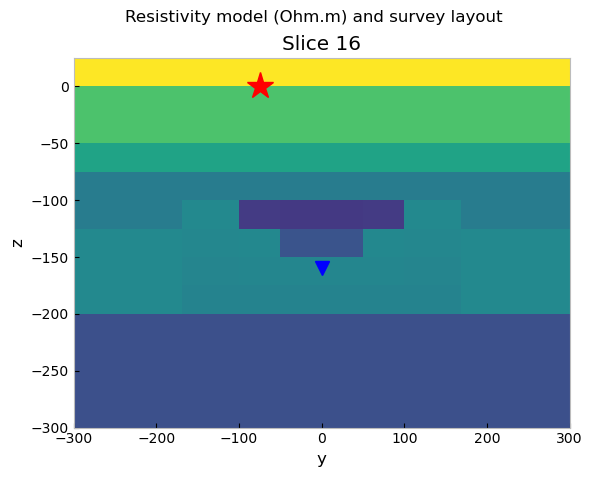

In [7]:
#Focus on the y,z plane
grid.plot_slice(
    model_target.property_x,
    normal = 'X',
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    range_x=[-300, 300],
    range_y=[-300, 25],
#    slice_loc=0
)
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = [rec_x, rec_y, rec_z]
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
src_coords = [src_x, src_y, src_z]
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
axs[1].grid(False)

#### Adjoint gradient

In [8]:
#Generate frequency- and source-dependent grids
gopts = {
    'properties': [25],
    'min_width_limits': [50, 50, 25],
    #'stretching': (None, None, [1.0, 1.5]),
    'domain': (
        [-100, 100],
        [-100, 100],
        [-250, 0]
    ),
    'center_on_edge': False,
}

In [9]:
#Create a survey design to generate measured data for each model (they are all the same, but have different names)

survey1 = emg3d.surveys.Survey(
    name='Survey 1',  # Name of the survey
    sources=src,               # Source coordinates
    receivers=rec,             # Receiver coordinates
    frequencies=frequencies,   # Two frequencies
    # data=data,               # Adding the observed data here will allow sensitivity calculation later, but we need to generate it first
    noise_floor=1e-15,
    relative_error=0.01,
)

In [11]:
#The simulation class contains all that is needed to forward-model the measurement: survey, model, grid, and solving parameters

simulation1 = emg3d.simulations.Simulation(
        name='Simulation 1',    # A name for this simulation
        survey=survey1,        # Our survey instance
        model=model_target,          # The model
        gridding='same',      # Frequency- and source-dependent meshes
        max_workers=4,        # How many parallel jobs
        # solver_opts,        # Any parameter to pass to emg3d.solve
        #gridding_opts=gopts,  # Gridding options
        receiver_interpolation = "linear" #Needed for correct computation of the gradient
    )

simulation1.compute(observed=True)

Compute efields            0/1  [00:00]

In [12]:
#The simulation contains the measured data (through the survey) and the details needed to forward-model the reference

simulation2 = emg3d.simulations.Simulation(
    name='Simulation 2',    # A name for this simulation
    survey=survey1,        # Our survey instance
    model=model_base,      # The model
    gridding='same',      # Frequency- and source-dependent meshes
    max_workers=4,        # How many parallel jobs
    # solver_opts,        # Any parameter to pass to emg3d.solve
    #gridding_opts=gopts,  # Gridding options
    receiver_interpolation = "linear" # Needed for correct computation of the gradient
)

simulation2.compute()
gradient = simulation2.gradient
misfit = simulation2.misfit
gradient_flat = gradient.ravel('F')
max_gradient = max(gradient_flat)
rel_gradient = np.divide(gradient_flat,max_gradient)

Compute efields            0/1  [00:00]

Back-propagate            0/1  [00:00]

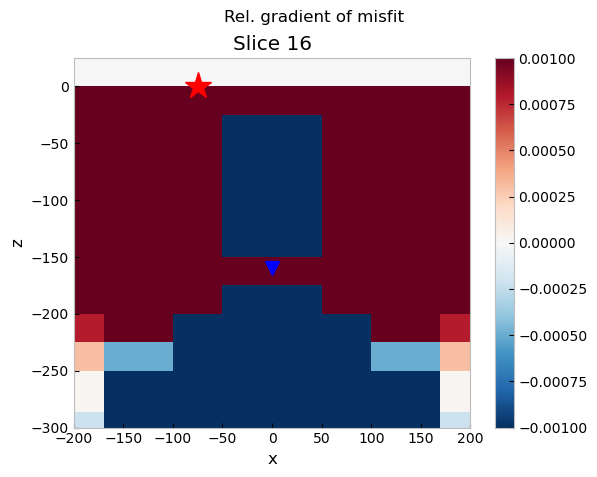

In [13]:
#Focus on the x,z plane

#Plot the simulated electric field
f0 = grid.plot_slice(
    rel_gradient,
    pcolor_opts={'cmap': 'RdBu_r',
             'norm': Normalize(vmin=-1e-3, vmax=1e-3)},
    normal = 'Y',
    range_x=[-200, 200], #y extent
    range_y=[-300, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle('Rel. gradient of misfit')
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey1.receiver_coordinates()
src_coords = survey1.source_coordinates()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax = axs[1])

#### FD gradient

In [14]:
data_misfit = misfit

In [15]:
# Define epsilon (some small resistivity value, Ohmm).
epsilon = 0.01

# Define the cross-section.
iy = grid.shape_cells[1]//2


def comp_fd_grad(ixiz):
    """Compute forward-FD gradient for one cell."""

    # Copy the computational model.
    fd_model = model_base.copy()

    # Add conductivity-epsilon to this (ix, iy, iz) cell.
    fd_model.property_x[ixiz[0], iy, ixiz[1]] += epsilon

    # Create a new simulation with this model
    simulation_fd = emg3d.simulations.Simulation(
        name='FD Gradient Test',
        survey=survey1, 
        model=fd_model,
        gridding='same',
        max_workers=1,
        solver_opts={'verb': 1},
        receiver_interpolation='linear',  # For proper adjoint-state gradient
    )

    # Switch-of progress bar in this case
    simulation_fd._tqdm_opts['disable'] = True

    # Get misfit
    fd_data_misfit = simulation_fd.misfit
    #print(fd_data_misfit)
    #print(data_misfit)
    #print(float((fd_data_misfit - data_misfit)/epsilon))

    # Return gradient
    return float((fd_data_misfit - data_misfit)/epsilon)

In [16]:
import itertools

In [32]:
# Initiate FD gradient.
fd_grad = np.zeros_like(gradient)

# Get all ix-iz combinations (without air/water).
ixiz = list(itertools.product(
    range(grid.shape_cells[0]),
    range(len(grid.cell_centers_z[grid.cell_centers_z < 0])))
)

# Wrap it asynchronously
#out = emg3d._multiprocessing.process_map(
#        comp_fd_grad,
#        ixiz,
#        max_workers=1,  # Adjust max worker here!
#)

mm = simulation1.model.grid
for i, (ix, iz) in enumerate(ixiz):
    if mm.nodes_x[ix] < -250 or mm.nodes_x[ix] > 250:
        continue
    if mm.nodes_z[iz] < -350 or mm.nodes_z[iz] > 0:
        continue
    fd_grad[ix, iy, iz] = comp_fd_grad([ix, iz])


# Collect result
#for i, (ix, iz) in enumerate(ixiz):
#    fd_grad[ix, iy, iz] = out[i]

In [33]:
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Rectangle

(array([1.2000e+01, 7.5400e+02, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

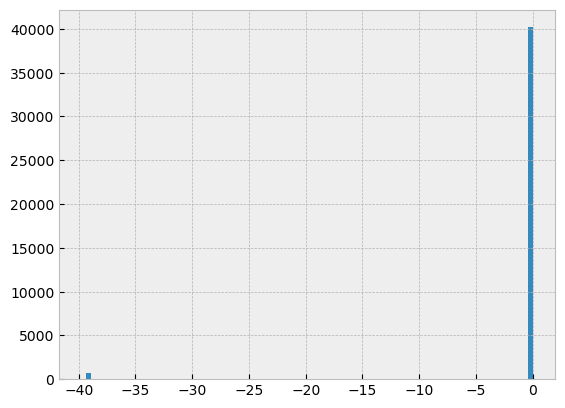

In [35]:
plt.hist(fd_grad.flatten(), bins=100)
#plt.ylim([0, 1000])
#plt.xlim([240000, 260000])

In [38]:
max_fd_grad = max(np.abs(fd_grad.flatten()))
print(max_fd_grad)
rel_fd_grad = 1-np.divide(np.abs(fd_grad.flatten()),max_fd_grad)

39.732559624490584


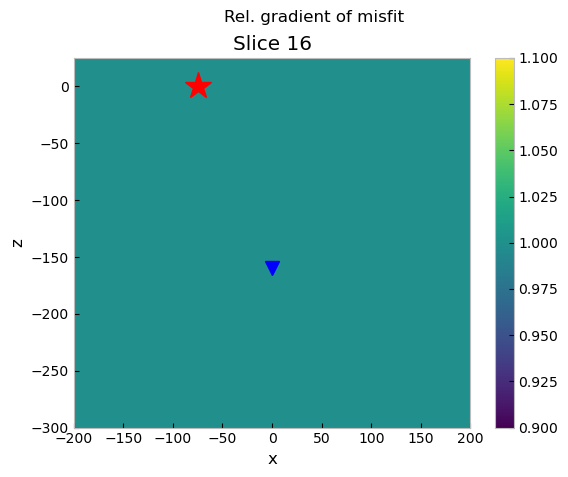

In [41]:
#Focus on the x,z plane (y=0)

f0 = grid.plot_slice(
    rel_fd_grad,
    #pcolor_opts={'cmap': 'RdBu_r',
    #         'norm': Normalize(vmin=0.005, vmax=2)},
    normal = 'Y',
    range_x=[-200, 200], #y extent
    range_y=[-300, 25], #z extent
    slice_loc=0 #, defaults to 0
)
fig = plt.gcf()
fig.suptitle('Rel. gradient of misfit')
axs = fig.get_children()
axs[1].grid(False)
rec_coords = survey1.receiver_coordinates()
src_coords = survey1.source_coordinates()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
fig.colorbar(f0[0], ax = axs[1])

353.72865733642334
0.0
0.0


C:\Users\suzannevannoor\AppData\Local\Temp\ipykernel_40532\2058314811.py:7: RuntimeWarning: overflow encountered in divide
  diff_sign = np.sign(gradient/np.where(abs(fd_grad) < tiny, tiny, fd_grad))
C:\Users\suzannevannoor\AppData\Local\Temp\ipykernel_40532\2058314811.py:77: RuntimeWarning: divide by zero encountered in divide
  f1 = grid.plot_slice(fd_grad/max_fd_grad, normal='Y', ind=iy, ax=axs[1],
C:\Users\suzannevannoor\AppData\Local\Temp\ipykernel_40532\2058314811.py:77: RuntimeWarning: invalid value encountered in divide
  f1 = grid.plot_slice(fd_grad/max_fd_grad, normal='Y', ind=iy, ax=axs[1],


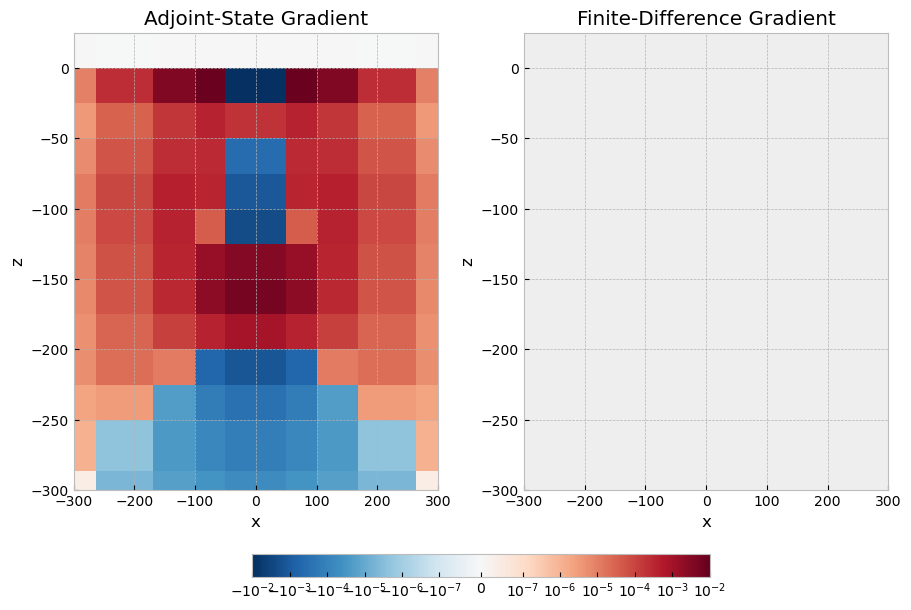

In [48]:
# Compute NRMSD between AS and FD (%).
nrmsd = 200*abs(gradient-fd_grad)/(abs(gradient)+abs(fd_grad))
nrmsd[fd_grad == 0] = np.nan

# Compute sign.
tiny = np.finfo(float).tiny  # Avoid division by zero.
diff_sign = np.sign(gradient/np.where(abs(fd_grad) < tiny, tiny, fd_grad))
    
    
def plot_diff(ax, diff):
    """Helper routine to show cells of big NRMSD or different sign."""

    for ix in range(grid.h[0].size):
        for iz in range(grid.h[2].size):

            if diff_sign[ix, iy, iz] < 0:
                ax.add_patch(
                        Rectangle(
                            (grid.nodes_x[ix], grid.nodes_z[iz]),
                            grid.h[0][ix], grid.h[2][iz], fill=False,
                            color='k', lw=1))

            if nrmsd[ix, iy, iz] >= diff:
                ax.add_patch(
                        Rectangle(
                            (grid.nodes_x[ix], grid.nodes_z[iz]),
                            grid.h[0][ix], grid.h[2][iz], fill=False,
                            color='m', linestyle='--', lw=0.5))


def set_axis(axs, i):
    """Helper routine to adjust subplots."""

    # Show source and receiver.
    axs[i].plot(rec_coords[0], rec_coords[2], 'bv')
    axs[i].plot(src_coords[0], src_coords[2], 'r*')

    # x-label.
    axs[i].set_xlabel('Easting')

    # y-label depending on column.
    if i == 0:
        axs[i].set_ylabel('Depth')
    else:
        axs[i].set_ylabel('')
        axs[i].axes.yaxis.set_ticklabels([])
    
    # Set limits.
    axs[i].set_xlim(-3000, 3000)
    axs[i].set_ylim(-4000, -1900)


# Plotting options.
vmin, vmax = 1e-7, 1e-2
pcolor_opts = {'cmap': 'RdBu_r',
               'norm': SymLogNorm(linthresh=vmin, base=10,
                                  vmin=-vmax, vmax=vmax)}

fig, axs = plt.subplots(
        figsize=(9, 6), nrows=1, ncols=2, constrained_layout=True)

max_grad = np.max(gradient)
print(max_grad)

# Adjoint-State Gradient
f0 = grid.plot_slice(gradient/max_grad, normal='Y', ind=iy, ax=axs[0],
                          pcolor_opts=pcolor_opts, range_x=[-300, 300], range_y=[-300, 25])
axs[0].set_title("Adjoint-State Gradient")
#set_axis(axs, 0)
#plot_diff(axs[0], 1)

max_fd_grad = np.max(fd_grad)
print(max_fd_grad)
print(fd_grad[15, 15, 15])

# Finite-Difference Gradient
f1 = grid.plot_slice(fd_grad/max_fd_grad, normal='Y', ind=iy, ax=axs[1],
                          pcolor_opts=pcolor_opts, range_x=[-300, 300], range_y=[-300, 25])
axs[1].set_title("Finite-Difference Gradient")
#set_axis(axs, 1)
#plot_diff(axs[1], 1)

fig.colorbar(f0[0], ax=axs, orientation='horizontal', fraction=0.05)